In [16]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import kagglehub
import os
from PIL import Image
import numpy as np

## **Load Dataset**

In [3]:
path = kagglehub.dataset_download("fahimabrarsami/brain-tumor")
print(path)

100%|██████████| 157M/157M [00:20<00:00, 8.05MB/s] 

Extracting files...


C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1


In [7]:
print(os.listdir(path))

['Testing', 'Training']


In [8]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print(train_path)
print(test_path)

C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1\Training
C:\Users\INTEL\.cache\kagglehub\datasets\fahimabrarsami\brain-tumor\versions\1\Testing


In [10]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

print("Training:")
print(os.listdir(train_path))

print("\nTesting:")
print(os.listdir(test_path))

Training:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [11]:
for cls in os.listdir(train_path):
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    print(f"{cls}:")
    print(f"  Training: {train_count}")
    print(f"  Testing : {test_count}")
    print()

glioma:
  Training: 1400
  Testing : 400

meningioma:
  Training: 1400
  Testing : 400

notumor:
  Training: 1400
  Testing : 400

pituitary:
  Training: 1400
  Testing : 400



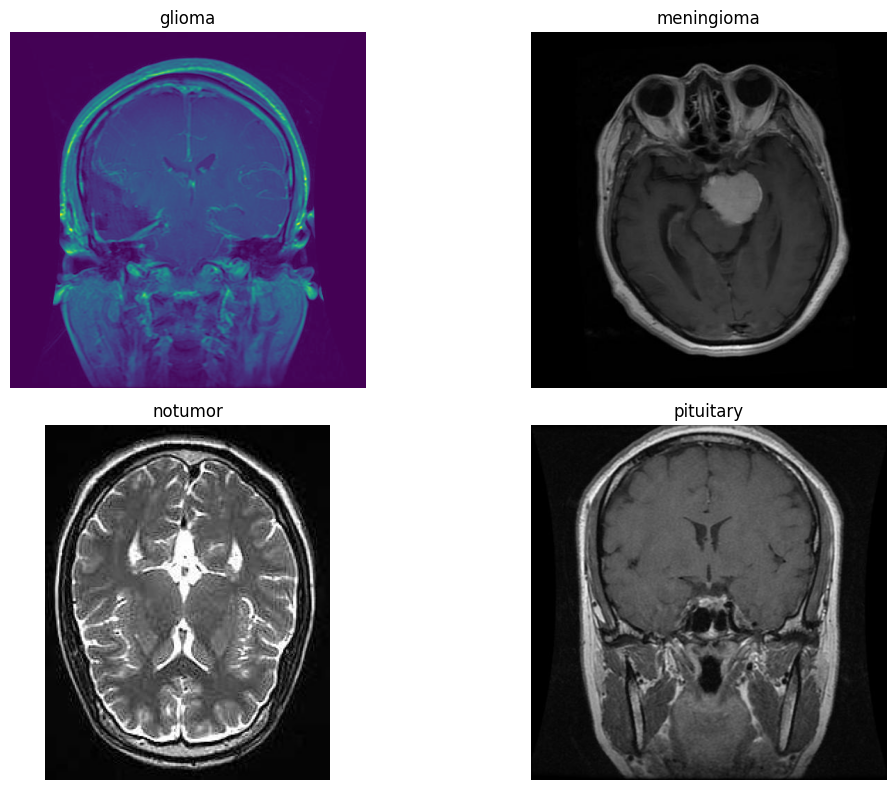

In [14]:
classes = os.listdir(train_path)

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for cls in classes:
    folder = os.path.join(train_path, cls)
    
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    
    image = Image.open(image_path)
    
    print(f"{cls}: {image.size}")

glioma: (512, 512)
meningioma: (512, 512)
notumor: (201, 251)
pituitary: (512, 512)


In [17]:
image_name = os.listdir(os.path.join(train_path, classes[0]))[0]
image_path = os.path.join(train_path, classes[0], image_name)

# Image load
image = Image.open(image_path).convert("RGB")

print("Original size:", image.size)

# Resize
image = image.resize((224, 224))

# Convert to NumPy array
image_array = np.array(image)

# Normalize
image_array = image_array / 255.0

print("After resize:", image_array.shape)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Original size: (512, 512)
After resize: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 0.9529411764705882


In [18]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
